In [1]:
%matplotlib widget

[VQE hydrogen molecule Qiskit code](https://arxiv.org/pdf/2305.06538)


pip install qiskit qiskit-nature[pyscf] matplotlib numpy

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Qiskit core
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import L_BFGS_B

# Qiskit Nature (second_q API)
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.problems import ElectronicStructureProblem
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

In [4]:
dist = 0.735
molecule = MoleculeInfo(
    symbols=["H", "H"],
    coords=[(0.0, 0.0, -dist/2), (0.0, 0.0, dist/2)],
    multiplicity=1,
    charge=0,
)

driver = PySCFDriver.from_molecule(molecule=molecule, basis="sto3g")
problem = driver.run()

In [5]:
freeze_core = FreezeCoreTransformer(freeze_core=True)
problem = freeze_core.transform(problem)

num_particles = problem.num_particles
num_spatial_orbitals = problem.num_spatial_orbitals
print(f"Particles: {num_particles}, Spatial orbitals: {num_spatial_orbitals}")

Particles: (1, 1), Spatial orbitals: 2


In [6]:
mapper = JordanWignerMapper()
hamiltonian = problem.hamiltonian.second_q_op()
qubit_op = mapper.map(hamiltonian)
print(f"Qubits: {qubit_op.num_qubits}")

Qubits: 4


In [7]:
initial_state = HartreeFock(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper,
)
ansatz = UCCSD(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper,
    initial_state=initial_state,
)
print(f"Parameters: {ansatz.num_parameters}")

Parameters: 3


In [8]:
optimizer = L_BFGS_B(maxiter=20)
estimator = StatevectorEstimator()   # exact simulation
vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)

In [9]:
result = vqe.compute_minimum_eigenvalue(qubit_op)
electronic_energy = result.eigenvalue.real
total_energy = electronic_energy + problem.nuclear_repulsion_energy

print(f"Electronic energy: {electronic_energy:.8f} Ha")
print(f"Nuclear repulsion: {problem.nuclear_repulsion_energy:.8f} Ha")
print(f"Total ground state energy: {total_energy:.8f} Ha")
print("Exact (paper): -1.857275 Ha")
print(f"Error: {abs(total_energy - (-1.857275)):.8f} Ha")

/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Electronic energy: -1.85727503 Ha
Nuclear repulsion: 0.71996899 Ha
Total ground state energy: -1.13730604 Ha
Exact (paper): -1.857275 Ha
Error: 0.71996896 Ha


/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: Spa

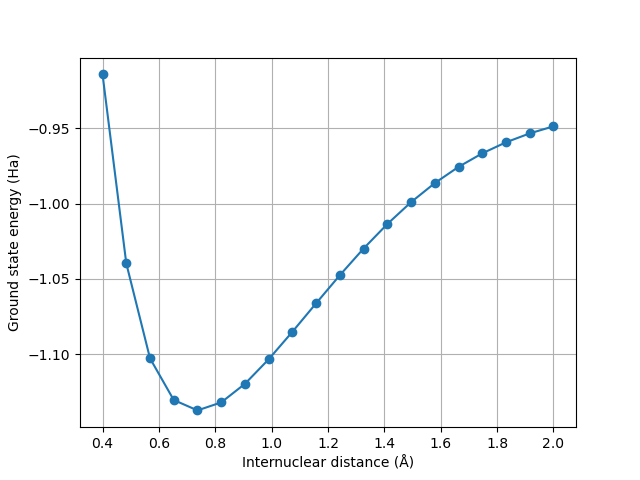

In [10]:
distances = np.linspace(0.4, 2.0, 20)
energies = []
for d in distances:
    mol = MoleculeInfo(
        symbols=["H", "H"],
        coords=[(0.0, 0.0, -d/2), (0.0, 0.0, d/2)],
        multiplicity=1,
        charge=0,
    )
    driver = PySCFDriver.from_molecule(molecule=mol, basis="sto3g")
    prob = driver.run()
    prob = FreezeCoreTransformer(freeze_core=True).transform(prob)
    ham = prob.hamiltonian.second_q_op()
    qubit_op = mapper.map(ham)
    ans = UCCSD(
        num_spatial_orbitals=prob.num_spatial_orbitals,
        num_particles=prob.num_particles,
        qubit_mapper=mapper,
        initial_state=HartreeFock(
            num_spatial_orbitals=prob.num_spatial_orbitals,
            num_particles=prob.num_particles,
            qubit_mapper=mapper,
        ),
    )
    vqe = VQE(estimator=StatevectorEstimator(), ansatz=ans, optimizer=L_BFGS_B(maxiter=20))
    res = vqe.compute_minimum_eigenvalue(qubit_op)
    energies.append(res.eigenvalue.real + prob.nuclear_repulsion_energy)

plt.plot(distances, energies, 'o-')
plt.xlabel("Internuclear distance (Å)")
plt.ylabel("Ground state energy (Ha)")
plt.grid()
plt.show()

In [11]:
print(distances )
print(energies )

[0.4        0.48421053 0.56842105 0.65263158 0.73684211 0.82105263
 0.90526316 0.98947368 1.07368421 1.15789474 1.24210526 1.32631579
 1.41052632 1.49473684 1.57894737 1.66315789 1.74736842 1.83157895
 1.91578947 2.        ]
[np.float64(-0.9141497046270071), np.float64(-1.039644193367129), np.float64(-1.1027234512173065), np.float64(-1.1303984654791508), np.float64(-1.1373027360289596), np.float64(-1.1320031440757237), np.float64(-1.1196476526566344), np.float64(-1.103357320120686), np.float64(-1.0850885605500227), np.float64(-1.0661536707140031), np.float64(-1.0474923241946164), np.float64(-1.0297900704160305), np.float64(-1.01352559100813), np.float64(-0.998995920249661), np.float64(-0.9863403143651418), np.float64(-0.9755678355209347), np.float64(-0.9665878877477199), np.float64(-0.9592413972810742), np.float64(-0.9533300339625526), np.float64(-0.9486411121760541)]


/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/robot-builder/miniconda3/envs/qiskit_wrk/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: Spa

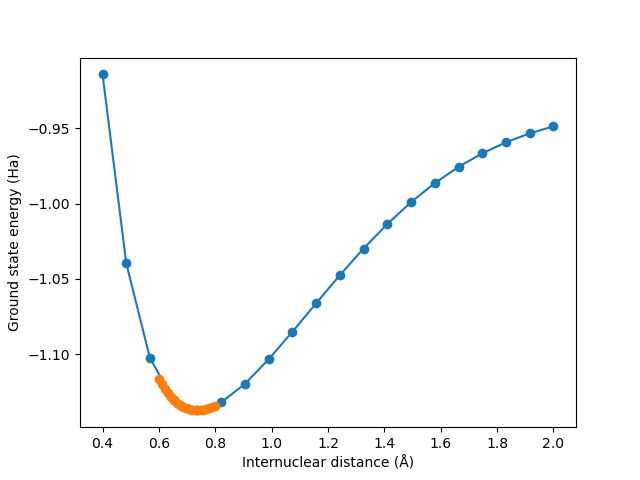

In [12]:
distances_conv = np.linspace(0.6, 0.8, 20)
energies_conv = []
for d in distances_conv:
    mol = MoleculeInfo(
        symbols=["H", "H"],
        coords=[(0.0, 0.0, -d/2), (0.0, 0.0, d/2)],
        multiplicity=1,
        charge=0,
    )
    driver = PySCFDriver.from_molecule(molecule=mol, basis="sto3g")
    prob = driver.run()
    prob = FreezeCoreTransformer(freeze_core=True).transform(prob)
    ham = prob.hamiltonian.second_q_op()
    qubit_op = mapper.map(ham)
    ans = UCCSD(
        num_spatial_orbitals=prob.num_spatial_orbitals,
        num_particles=prob.num_particles,
        qubit_mapper=mapper,
        initial_state=HartreeFock(
            num_spatial_orbitals=prob.num_spatial_orbitals,
            num_particles=prob.num_particles,
            qubit_mapper=mapper,
        ),
    )
    vqe = VQE(estimator=StatevectorEstimator(), ansatz=ans, optimizer=L_BFGS_B(maxiter=20))
    res = vqe.compute_minimum_eigenvalue(qubit_op)
    energies_conv.append(res.eigenvalue.real + prob.nuclear_repulsion_energy)

plt.plot(distances_conv, energies_conv, 'o-')
plt.xlabel("Internuclear distance (Å)")
plt.ylabel("Ground state energy (Ha)")
plt.grid()
plt.show()


In [13]:
print(distances_conv )
print(energies_conv )

[0.6        0.61052632 0.62105263 0.63157895 0.64210526 0.65263158
 0.66315789 0.67368421 0.68421053 0.69473684 0.70526316 0.71578947
 0.72631579 0.73684211 0.74736842 0.75789474 0.76842105 0.77894737
 0.78947368 0.8       ]
[np.float64(-1.1162860068561453), np.float64(-1.1198833815246994), np.float64(-1.1230677941347436), np.float64(-1.1258656106869322), np.float64(-1.1283014798742839), np.float64(-1.1303984654806225), np.float64(-1.13217816423772), np.float64(-1.1336608124587162), np.float64(-1.1348653812523817), np.float64(-1.1358096632341945), np.float64(-1.136510350954139), np.float64(-1.136983108506418), np.float64(-1.1372426372050795), np.float64(-1.1373027360311698), np.float64(-1.1371763574964804), np.float64(-1.1368756597952387), np.float64(-1.1364120550000891), np.float64(-1.1357962548381544), np.float64(-1.135038313229881), np.float64(-1.1341476666688377)]


In [14]:
# Find the minimum energy and its index
min_energy = min(energies)
min_index = energies.index(min_energy)
equilibrium_distance = distances[min_index]

print(f"Minimum ground state energy: {min_energy:.8f} Ha")
print(f"Equilibrium bond distance: {equilibrium_distance:.4f} Å")

Minimum ground state energy: -1.13730274 Ha
Equilibrium bond distance: 0.7368 Å


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.interpolate import interp1d
from IPython.display import HTML

# ====================== PASTE YOUR DATA HERE ======================
# distances in Å (Angstrom), energies in any unit (Hartree, eV, etc.)
your_distances = np.array(distances_conv) # ← CHANGE THIS
your_energies  = np.array(energies_conv) # ← CHANGE THIS

# Sort just in case
sort_idx = np.argsort(your_distances)
distances = your_distances[sort_idx]
energies  = your_energies[sort_idx]
# =================================================================

In [16]:
# Create interpolator (cubic is smooth)
V = interp1d(distances, energies, kind='cubic', fill_value="extrapolate", bounds_error=False)

# Find equilibrium distance (minimum energy)
idx_min = np.argmin(energies)
r_eq = distances[idx_min]
E_min = energies[idx_min]

print(f"Equilibrium distance from your data = {r_eq:.3f} Å")
print(f"Minimum energy from your data = {E_min:.5f}")

Equilibrium distance from your data = 0.737 Å
Minimum energy from your data = -1.13730


In [17]:
# Approximate force constant k (second derivative at minimum)
dr = 1e-4
k = (V(r_eq + dr) - 2*V(r_eq) + V(r_eq - dr)) / (dr**2)

# Choose amplitude (how much it vibrates) - you can change this
amplitude = 0.15   # Å

# Time array for one full vibration (30 frames per cycle)
t = np.linspace(0, 2*np.pi, 120)          # 120 frames = smooth loop
omega = np.sqrt(k)                        # frequency (arbitrary mass scaling)
r_trajectory = r_eq + amplitude * np.cos(omega * t)

# Pre-calculate energies along the trajectory
E_trajectory = V(r_trajectory)

print("Simulation ready — now run the animation cell below")

Simulation ready — now run the animation cell below


In [19]:
# !conda install -c conda-forge ipympl -y


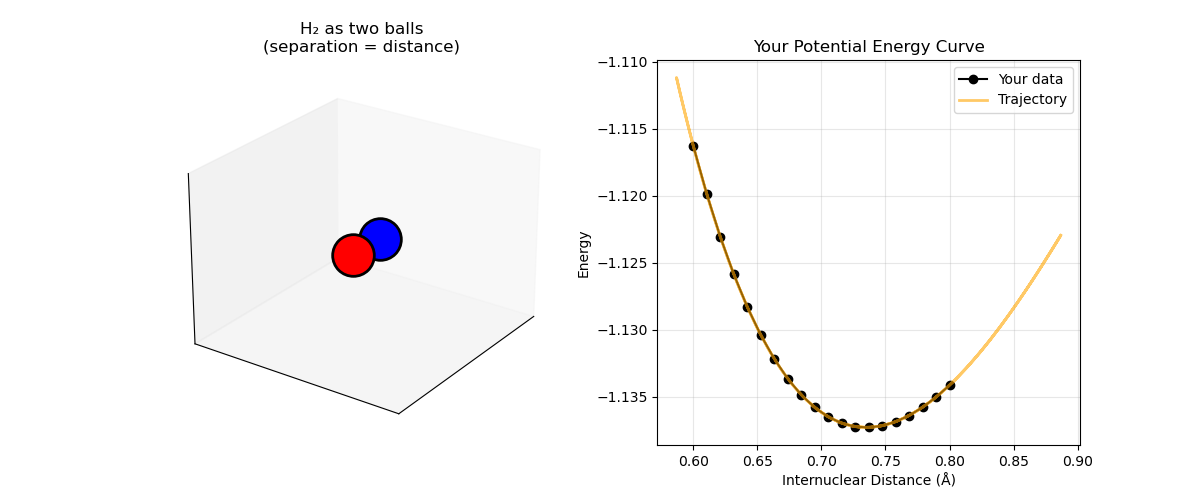

In [20]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

# ====================== FIGURE SETUP ======================
fig = plt.figure(figsize=(12, 5))

# ====================== LEFT PANEL: 3D (MOUSE ROTATABLE) ======================
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

ax1.set_xlim3d(-2, 2)
ax1.set_ylim3d(-1, 1)
ax1.set_zlim3d(-1, 1)

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])

ax1.set_title('H₂ as two balls\n(separation = distance)')
ax1.view_init(elev=25, azim=35)      # starting angle

ball_size = 900                      # ← change if balls too big/small

# Two atoms
scat_left  = ax1.scatter([-r_eq/2], [0], [0], s=ball_size, c='blue',  edgecolor='black', linewidth=2)
scat_right = ax1.scatter([ r_eq/2], [0], [0], s=ball_size, c='red',   edgecolor='black', linewidth=2)

# Bond line
bond_line, = ax1.plot3D([], [], [], color='gray', lw=4)

# ====================== RIGHT PANEL: Energy curve ======================
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(distances, energies, 'o-', color='black', label='Your data')
ax2.plot(r_trajectory, E_trajectory, color='orange', lw=2, alpha=0.6, label='Trajectory')
ax2.set_xlabel('Internuclear Distance (Å)')
ax2.set_ylabel('Energy')
ax2.set_title('Your Potential Energy Curve')
ax2.grid(True, alpha=0.3)
ax2.legend()

marker, = ax2.plot([], [], 'o', color='red', markersize=10)

# ====================== ANIMATION ======================
def animate(frame):
    r = r_trajectory[frame]
    
    # Update 3D positions
    scat_left._offsets3d = (np.array([-r/2]), np.array([0.]), np.array([0.]))
    scat_right._offsets3d = (np.array([r/2]), np.array([0.]), np.array([0.]))
    
    # Update bond
    bond_line.set_data_3d([-r/2, r/2], [0, 0], [0, 0])
    
    # Update energy marker
    marker.set_data([r], [V(r)])
    
    return scat_left, scat_right, bond_line, marker

anim = FuncAnimation(
    fig, animate,
    frames=len(r_trajectory),
    interval=40,
    blit=False,          # important for notebook backend
    repeat=True
)

plt.show()
anim